## môn: khoa học dữ liệu
## bài tập lớn
######
đề: Phân tích điểm số học tập của sinh viên lớp K58KTP
dữ liệu: Dữ liệu điểm thực tế của lớp K58KTP

1, Tên đề tài

2, Bộ dữ liệu gì

3, 5 câu hỏi về phân tích dữ liệu sẽ trả lời là gì''

- xu hướng biến động điểm theo thời gian
Xu hướng điểm tích lũy biến động như thế nào theo trục thời gian? Kỳ học nào ghi nhận điểm số đạt đỉnh và chạm đáy?
- so sánh độ chênh lệch của kì 1,2,3 giữa các năm học
Sự chênh lệnh điểm của các kì học giữa các năm học như thế nào?
- mức độ phân hóa điểm giữa các năm
Biên độ phân hóa điểm số của lớp K58KTP dịch chuyển như thế nào qua từng năm học? Sinh viên có xu hướng phân hóa mạnh hơn hay đồng đều hơn khi lên các năm cuối?
- tương quan điểm giữa các môn đại cương và chuyên ngành
Tương quan điểm giữa các môn đại cương và chuyên ngành cao hay thấp?
- phần trăm của trường hợp điểm ổn định/không ổn định/tiến bộ
Tỷ lệ phần trăm phân bổ của các hình thái học tập trong lớp cụ thể là bao nhiêu (Nhóm Ổn định/nhóm Sa sút/nhóm Tiến bộ)?

4, "2 câu hỏi về dự đoán, hoạc phân cụm, hoặc phân lớp sẽ trả lời là gì?
- phân loại sinh viên theo mức độ điểm của lớp
Khi áp dụng thuật toán phân cụm K-Means, ta thu được những hình thái tiến trình học tập đặc trưng nào của lớp học, và đặc điểm chung của mỗi nhóm là gì?
- xác định mức độ học tập hiệu quả của các học kì
Từ phân tích điểm số của lớp, mức độ học tập hiệu quả theo từng kì và năm học đạt mức nào?

In [57]:
# ==============================================================================
# CELL 1: IMPORT THƯ VIỆN & CẤU HÌNH ĐỒ THỊ TIẾNG VIỆT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from sklearn.cluster import KMeans
import matplotlib.font_manager as fm
import os # Import the os module
import matplotlib as mpl # Import matplotlib to get its cache directory

# Correctly download font Roboto to display Vietnamese characters on matplotlib plots in Colab
# Using -O to specify output file and a direct raw link to the ttf file
!wget -q -O /content/Roboto-Regular.ttf https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Regular.ttf

font_path = '/content/Roboto-Regular.ttf'

# Clear matplotlib's font cache to ensure the new font is loaded correctly
cache_dir = mpl.get_cachedir()
# Matplotlib's font cache file name can vary, so iterate and remove any existing fontlist files
for filename in os.listdir(cache_dir):
    if filename.startswith('fontlist-') and filename.endswith('.json'):
        full_path = os.path.join(cache_dir, filename)
        os.remove(full_path)
        print(f"Removed matplotlib font cache file: {full_path}")

try:
    # Add the font to Matplotlib's font manager
    fm.fontManager.addfont(font_path)
    # Force rebuild the font cache. findfont will trigger this if rebuild_if_missing is True
    fm.findfont('Roboto-Regular', fontext='ttf', rebuild_if_missing=True)

    plt.rcParams['font.family'] = 'Roboto-Regular'
    plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly

    print("Font 'Roboto-Regular' configured successfully.")
except Exception as e:
    print(f"Error configuring font: {e}")
    print("Font configuration failed. Plots may not display Vietnamese characters correctly.")

print("Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!")

Error configuring font: 
Roboto-Regular
      ^
ParseException: Expected end of text, found '-'  (at char 6), (line:1, col:7)
Font configuration failed. Plots may not display Vietnamese characters correctly.
Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!


In [58]:
# ==============================================================================
# CELL 2: ĐỌC DỮ LIỆU TỪ FILE EXCEL NGUỒN
# ==============================================================================
file_path = "/content/drive/MyDrive/Colab Notebooks/TỔNG HỢP ĐIỂM K58KTP.xlsx"

# Đọc cấu trúc thô của bảng điểm, bỏ qua lỗi ký tự đặc biệt
df_raw = pd.read_excel(file_path, header=None)

print(f"Kích thước tệp ma trận điểm số gốc: {df_raw.shape}")

# Trích xuất thông tin định danh sinh viên từ dòng 1 và dòng 2
mssv_row = df_raw.iloc[1, 3:].values
tensv_row = df_raw.iloc[2, 3:].values

# Trích xuất số tín chỉ của từng môn học (Cột số 2, Dòng 4 trở đi)
# Lưu ý: Điểm số của môn bắt đầu tính từ dòng số 4
tin_chi_raw = df_raw.iloc[4:, 2].values # Corrected extraction for credits
tin_chi_series = pd.to_numeric(pd.Series(tin_chi_raw).astype(str).str.replace(',', '.', regex=True), errors='coerce')
tin_chi = tin_chi_series.fillna(2.0).values # Mặc định gán 2 tín chỉ nếu ô dữ liệu bị trống

print(f"Tổng số sinh viên ghi nhận ban đầu: {len(mssv_row)}")
print(f"Tổng số môn học ghi nhận ban đầu: {len(tin_chi)}")

Kích thước tệp ma trận điểm số gốc: (56, 77)
Tổng số sinh viên ghi nhận ban đầu: 74
Tổng số môn học ghi nhận ban đầu: 52


In [49]:
# ==============================================================================
# CELL 3: TIỀN XỬ LÝ DỮ LIỆU ĐỘNG & TÍNH TOÁN TIẾN TRÌNH GPA THEO NĂM HỌC
# ==============================================================================

# Hàm chuẩn hóa làm sạch dữ liệu đầu điểm
def chuan_hoa_diem(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower().replace('nan', '')
    if s in ['-', '—', 'x', '', '0', '0.0']: # Bỏ qua ô trống hoặc ký tự đặc biệt
        return np.nan
    try:
        f = float(s)
        return f if 0 <= f <= 4.0 else np.nan
    except:
        return np.nan

# 1. Trích xuất thông tin cấu trúc danh mục môn học (Dòng 4 trở đi)
ma_mon_series  = df_raw.iloc[4:, 1].values   # Cột 2: Mã môn học
tin_chi_raw    = df_raw.iloc[4:, 2].values   # Cột 3: Số tín chỉ
hoc_ky_series  = pd.to_numeric(df_raw.iloc[4:, 3], errors='coerce').values # Cột 4: Kỳ học
nam_hoc_series = pd.to_numeric(df_raw.iloc[4:, 4], errors='coerce').values # Cột 5: Năm học
ten_mon_series = df_raw.iloc[4:, 5].values   # Cột 6: Tên môn học

# Chuẩn hóa mảng số tín chỉ về dạng số thực (Mặc định gán 2 TC nếu ô trống)
tin_chi_series = pd.to_numeric(pd.Series(tin_chi_raw).astype(str).str.replace(',', '.'), errors='coerce').fillna(2.0).values

# 2. Trích xuất và làm sạch ma trận điểm số thực tế của sinh viên (Từ cột 7 trở đi)
matrix_diem = df_raw.iloc[4:, 6:].copy()
for col in matrix_diem.columns:
    matrix_diem[col] = matrix_diem[col].apply(chuan_hoa_diem)

# Đồng bộ danh sách định danh Sinh viên tương ứng từ các cột điểm
mssv_filtered = df_raw.iloc[1, 6:].values
tensv_filtered = df_raw.iloc[2, 6:].values

# 3. Thuật toán lõi tính toán GPA tiến trình (Hệ 4) có trọng số tín chỉ cho từng cá nhân
gpa_toan_khoa = []
gpa_nam_1 = []
gpa_nam_2 = []
gpa_nam_3 = []
gpa_nam_4 = []

for col in matrix_diem.columns:
    diem_sinh_vien = matrix_diem[col].values

    # Hàm tính toán GPA cục bộ loại bỏ hoàn toàn các ô trống (NaN) của sinh viên
    def tinh_gpa_theo_bo_loc(mask_dieu_kien):
        diem_hop_le = diem_sinh_vien[mask_dieu_kien]
        tin_chi_hop_le = tin_chi_series[mask_dieu_kien]

        # Chỉ lọc lấy các môn thực tế sinh viên đó có đầu điểm
        cac_mon_da_hoc = ~np.isnan(diem_hop_le)

        if not np.any(cac_mon_da_hoc):
            return np.nan # Trả về NaN nếu sinh viên chưa tích lũy môn nào trong giai đoạn này

        return np.sum(diem_hop_le[cac_mon_da_hoc] * tin_chi_hop_le[cac_mon_da_hoc]) / np.sum(tin_chi_hop_le[cac_mon_da_hoc])

    # Tính toán dải điểm tiến trình theo từng bộ lọc dòng thời gian
    gpa_toan_khoa.append(tinh_gpa_theo_bo_loc(slice(None))) # Tất cả các môn
    gpa_nam_1.append(tinh_gpa_theo_bo_loc(nam_hoc_series == 1))
    gpa_nam_2.append(tinh_gpa_theo_bo_loc(nam_hoc_series == 2))
    gpa_nam_3.append(tinh_gpa_theo_bo_loc(nam_hoc_series == 3))
    gpa_nam_4.append(tinh_gpa_theo_bo_loc(nam_hoc_series == 4))

# 4. Đóng gói toàn bộ đặc trưng chuỗi thời gian vào DataFrame tổng hợp
features_filtered = pd.DataFrame({
    'MSSV': mssv_filtered,
    'Ten_SV': tensv_filtered,
    'GPA': gpa_toan_khoa,
    'GPA_Nam1': gpa_nam_1,
    'GPA_Nam2': gpa_nam_2,
    'GPA_Nam3': gpa_nam_3,
    'GPA_Nam4': gpa_nam_4
})

# Điền giá trị trung bình lớp cho các ô năm học bị khuyết (nếu có sinh viên bảo lưu hoặc chưa học năm đó)
features_filtered['GPA_Nam1'] = features_filtered['GPA_Nam1'].fillna(features_filtered['GPA_Nam1'].mean())
features_filtered['GPA_Nam2'] = features_filtered['GPA_Nam2'].fillna(features_filtered['GPA_Nam2'].mean())
features_filtered['GPA_Nam3'] = features_filtered['GPA_Nam3'].fillna(features_filtered['GPA_Nam3'].mean())
features_filtered['GPA_Nam4'] = features_filtered['GPA_Nam4'].fillna(features_filtered['GPA_Nam4'].mean())
features_filtered['GPA'] = features_filtered['GPA'].fillna(features_filtered['GPA'].mean())

print(f"Xử lý hoàn tất! Đã trích xuất ma trận điểm tiến trình thời gian cho {len(features_filtered)} sinh viên.")
print(f"Số lượng đầu môn học ghi nhận: {len(ma_mon_series)} môn.")
print("\nXem trước bảng dữ liệu cấu trúc chuỗi thời gian mới:")
print(features_filtered[['MSSV', 'Ten_SV', 'GPA_Nam1', 'GPA_Nam2', 'GPA_Nam3', 'GPA_Nam4', 'GPA']].head(5))

Xử lý hoàn tất! Đã trích xuất ma trận điểm tiến trình thời gian cho 71 sinh viên.
Số lượng đầu môn học ghi nhận: 52 môn.

Xem trước bảng dữ liệu cấu trúc chuỗi thời gian mới:
            MSSV           Ten_SV  GPA_Nam1  GPA_Nam2  GPA_Nam3  GPA_Nam4  \
0  K225480106002  Nguyễn Tuấn Anh  2.272727  2.071429  2.562500  2.333333   
1  K225480106095  Nguyễn Tuấn Anh  1.857143  2.257576  2.545714  2.771429   
2  K225510201001     Bùi Ngọc Anh  2.181818  1.900000  2.166667  2.600000   
3  K225480106082      Vũ Việt Anh  1.696000  1.842105  2.411765  3.028571   
4  K225480106001      Lê Tuấn Anh  2.071429  2.111765  2.705405  3.112500   

        GPA  
0  2.311475  
1  2.340171  
2  2.185714  
3  2.186441  
4  2.476423  


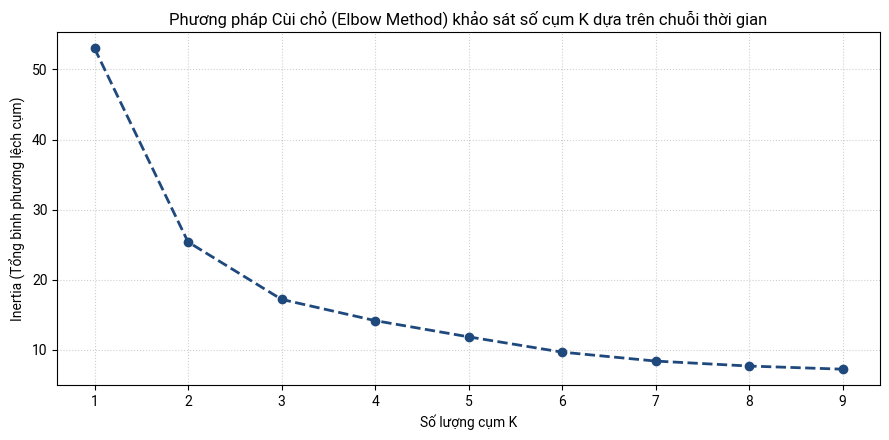

Mẹo phân tích: Điểm gãy khúc rõ nhất thường xuất hiện tại K = 3, đại diện cho 3 trạng thái tiến trình học tập của lớp.


In [50]:
# ==============================================================================
# CELL 4: PHƯƠNG PHÁP ĐƯỜNG CONG CÙI CHỎ (ELBOW METHOD ĐA CHIỀU)
# ==============================================================================
# Trích xuất vectơ chuỗi thời gian điểm số qua 4 năm làm dữ liệu đầu vào mô hình
X_timeline = features_filtered[['GPA_Nam1', 'GPA_Nam2', 'GPA_Nam3', 'GPA_Nam4']].values

inertia_timeline = []
K_range = range(1, 10)

for k in K_range:
    model_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    model_k.fit(X_timeline)
    inertia_timeline.append(model_k.inertia_)

# Vẽ biểu đồ đường cong cùi chỏ
plt.figure(figsize=(9, 4.5))
plt.plot(K_range, inertia_timeline, marker='o', color='#1F497D', linestyle='--', linewidth=2)
plt.title("Phương pháp Cùi chỏ (Elbow Method) khảo sát số cụm K dựa trên chuỗi thời gian", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng cụm K", fontsize=10)
plt.ylabel("Inertia (Tổng bình phương lệch cụm)", fontsize=10)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Mẹo phân tích: Điểm gãy khúc rõ nhất thường xuất hiện tại K = 3, đại diện cho 3 trạng thái tiến trình học tập của lớp.")

In [51]:
# ==============================================================================
# CELL 5: TÍNH TOÁN DỮ LIỆU EDA MỞ RỘNG & 2 MÔ HÌNH HỌC MÁY CHUYÊN SÂU
# ==============================================================================
import scipy.stats as stats

# ------------------------------------------------------------------------------
# CẤU HÌNH: CHỌN TÊN SINH VIÊN ĐỂ PHÂN TÍCH CHI TIẾT
# ------------------------------------------------------------------------------
TEN_SV_LUA_CHON = "Dương Quang Minh"

if TEN_SV_LUA_CHON not in features_filtered['Ten_SV'].values:
    print(f" Cảnh báo: Không tìm thấy sinh viên '{TEN_SV_LUA_CHON}'!")
    TEN_SV_LUA_CHON = features_filtered['Ten_SV'].iloc[0]
    print(f"Hệ thống tự động chọn sinh viên mẫu: {TEN_SV_LUA_CHON}")

sv_data = features_filtered[features_filtered['Ten_SV'] == TEN_SV_LUA_CHON].iloc[0]
sv_idx_in_matrix = list(features_filtered['Ten_SV'].values).index(TEN_SV_LUA_CHON)
col_name_of_sv = matrix_diem.columns[sv_idx_in_matrix]
diem_tho_sv = matrix_diem[col_name_of_sv].values

# --- Câu 1: Xu hướng biến động điểm theo thời gian ---
lop_means = [features_filtered['GPA_Nam1'].mean(), features_filtered['GPA_Nam2'].mean(),
             features_filtered['GPA_Nam3'].mean(), features_filtered['GPA_Nam4'].mean()]
sv_means = [sv_data['GPA_Nam1'], sv_data['GPA_Nam2'], sv_data['GPA_Nam3'], sv_data['GPA_Nam4']]

# --- Câu 2: Tính toán chi tiết cho 11 Kỳ học (Năm 1 -> Năm 4) ---
danh_sach_ky_hoc = [
    (1, 1), (1, 2), (1, 3), # Năm 1
    (2, 1), (2, 2), (2, 3), # Năm 2
    (3, 1), (3, 2), (3, 3), # Năm 3
    (4, 1), (4, 2)          # Năm 4 (Bỏ qua kì 3 năm 4)
]

labels_11_ky = []
lop_means_11_ky = []
sv_means_11_ky = []

for nam, ky in danh_sach_ky_hoc:
    label_name = f"N{nam}K{ky}"
    labels_11_ky.append(label_name)
    ky_mask = (nam_hoc_series == nam) & (hoc_ky_series == ky)

    # Mức điểm trung bình của tập thể lớp tại kỳ này
    scores_lop_ky = []
    for col in matrix_diem.columns:
        d_raw_sv = matrix_diem[col].values[ky_mask]
        valid_d = d_raw_sv[~np.isnan(d_raw_sv)]
        if len(valid_d) > 0:
            scores_lop_ky.append(np.mean(valid_d))
    lop_means_11_ky.append(np.mean(scores_lop_ky) if scores_lop_ky else np.nan)

    # Mức điểm riêng của sinh viên lựa chọn tại kỳ này
    d_sv_ky = diem_tho_sv[ky_mask]
    valid_d_sv_ky = d_sv_ky[~np.isnan(d_sv_ky)]
    sv_means_11_ky.append(np.mean(valid_d_sv_ky) if len(valid_d_sv_ky) > 0 else np.nan)

# Xử lý nội suy điền giá trị khuyết (nếu kỳ học đó sinh viên không đăng ký môn nào)
lop_means_11_ky = pd.Series(lop_means_11_ky).fillna(method='ffill').fillna(method='bfill').tolist()
sv_means_11_ky = pd.Series(sv_means_11_ky).fillna(method='ffill').fillna(method='bfill').tolist()

# --- Câu 3: Tính chỉ số phân hóa (Std) và vị thế tương đối (Z-Score) ---
lop_stds = [features_filtered['GPA_Nam1'].std(), features_filtered['GPA_Nam2'].std(),
            features_filtered['GPA_Nam3'].std(), features_filtered['GPA_Nam4'].std()]
sv_z_scores = []
for idx, col_nam in enumerate(['GPA_Nam1', 'GPA_Nam2', 'GPA_Nam3', 'GPA_Nam4']):
    z = (sv_means[idx] - lop_means[idx]) / lop_stds[idx] if lop_stds[idx] > 0 else 0
    sv_z_scores.append(z)

# --- Câu 4: Tính hệ số tương quan giữa các năm học ---
correlation_matrix = features_filtered[['GPA_Nam1', 'GPA_Nam2', 'GPA_Nam3', 'GPA_Nam4']].corr()

# --- Câu 5: Phân chia cơ cấu hình thái học tập ---
delta_gpa_all = features_filtered['GPA_Nam4'] - features_filtered['GPA_Nam1']
def phan_loai_tien_trinh(val):
    if val > 0.25: return "Tiến bộ bứt phá"
    elif val < -0.25: return "Không ổn định (Sa sút)"
    else: return "Phong độ Ổn định"

features_filtered['Hinh_Thai_Tien_Trinh'] = delta_gpa_all.apply(phan_loai_tien_trinh)
counts_progress = features_filtered['Hinh_Thai_Tien_Trinh'].value_counts()
sv_progress_label = phan_loai_tien_trinh(sv_data['GPA_Nam4'] - sv_data['GPA_Nam1'])

# ------------------------------------------------------------------------------
# TÍNH TOÁN 2 CÂU HỎI MÔ HÌNH HÓA (MACHINE LEARNING)
# ------------------------------------------------------------------------------

# --- Mô hình 1: Phân loại sinh viên (K-Means đa chiều) ---
X_timeline = features_filtered[['GPA_Nam1', 'GPA_Nam2', 'GPA_Nam3', 'GPA_Nam4']].values
kmeans_timeline = KMeans(n_clusters=3, random_state=42, n_init=10)
features_filtered['Cluster_Label'] = kmeans_timeline.fit_predict(X_timeline)

cluster_gpa_means = features_filtered.groupby('Cluster_Label')['GPA'].mean().sort_values()
cluster_mapping = {
    cluster_gpa_means.index[0]: "Trung bình / Yếu",
    cluster_gpa_means.index[1]: "Khá",
    cluster_gpa_means.index[2]: "Giỏi"
}
features_filtered['Ten_Nhom_Cum'] = features_filtered['Cluster_Label'].map(cluster_mapping)
sv_cluster_label = features_filtered[features_filtered['Ten_SV'] == TEN_SV_LUA_CHON]['Ten_Nhom_Cum'].values[0]

# --- Mô hình 2: Phân cụm các Học kỳ dựa trên đặc trưng phổ điểm sinh viên ---
matrix_11_ky_clean = pd.DataFrame()
for idx, (nam, ky) in enumerate(danh_sach_ky_hoc):
    ky_mask = (nam_hoc_series == nam) & (hoc_ky_series == ky)
    student_means_in_ky = []
    for col in matrix_diem.columns:
        d_array = matrix_diem[col].values[ky_mask]
        valid_points = d_array[~np.isnan(d_array)]
        student_means_in_ky.append(np.mean(valid_points) if len(valid_points) > 0 else 0)
    matrix_11_ky_clean[f"N{nam}K{ky}"] = student_means_in_ky

# Tính toán các đặc trưng: Điểm trung bình kỳ và Độ lệch chuẩn kỳ
features_hk = pd.DataFrame({
    'Mean_Score': matrix_11_ky_clean.mean(),
    'Std_Score': matrix_11_ky_clean.std()
})

X_hk = features_hk.values
kmeans_hk = KMeans(n_clusters=2, random_state=42, n_init=10)
features_hk['Cluster_Label'] = kmeans_hk.fit_predict(X_hk)

# Định nghĩa nhãn cụm học kỳ dựa trên mức độ điểm số
hk_cluster_means = features_hk.groupby('Cluster_Label')['Mean_Score'].mean().sort_values()
hk_mapping = {
    hk_cluster_means.index[0]: "Kỳ học Thách thức (Điểm thấp/Phân hóa cao)",
    hk_cluster_means.index[1]: "Kỳ học Hiệu quả tốt (Mức tiếp thu đồng đều)"
}
features_hk['Ten_Cum_Ky'] = features_hk['Cluster_Label'].map(hk_mapping)

print("\n--- HOÀN THÀNH TÍNH TOÁN DỮ LIỆU ---")
print(f"Đã trích xuất tiến trình của {len(labels_11_ky)} học kỳ cốt lõi.")


--- HOÀN THÀNH TÍNH TOÁN DỮ LIỆU ---
Đã trích xuất tiến trình của 11 học kỳ cốt lõi.


/tmp/ipykernel_4250/1771641470.py:58: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lop_means_11_ky = pd.Series(lop_means_11_ky).fillna(method='ffill').fillna(method='bfill').tolist()
/tmp/ipykernel_4250/1771641470.py:59: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sv_means_11_ky = pd.Series(sv_means_11_ky).fillna(method='ffill').fillna(method='bfill').tolist()


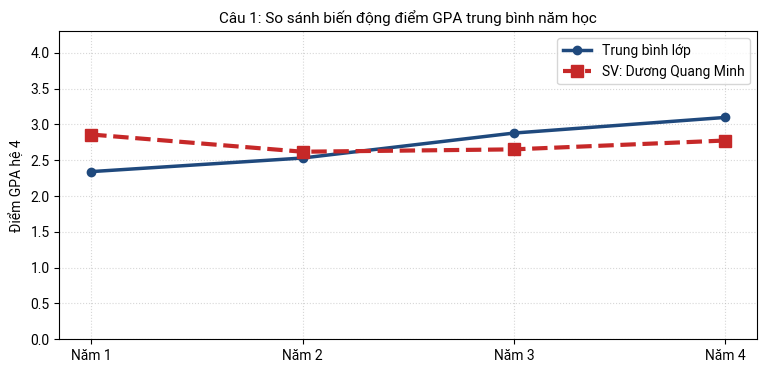

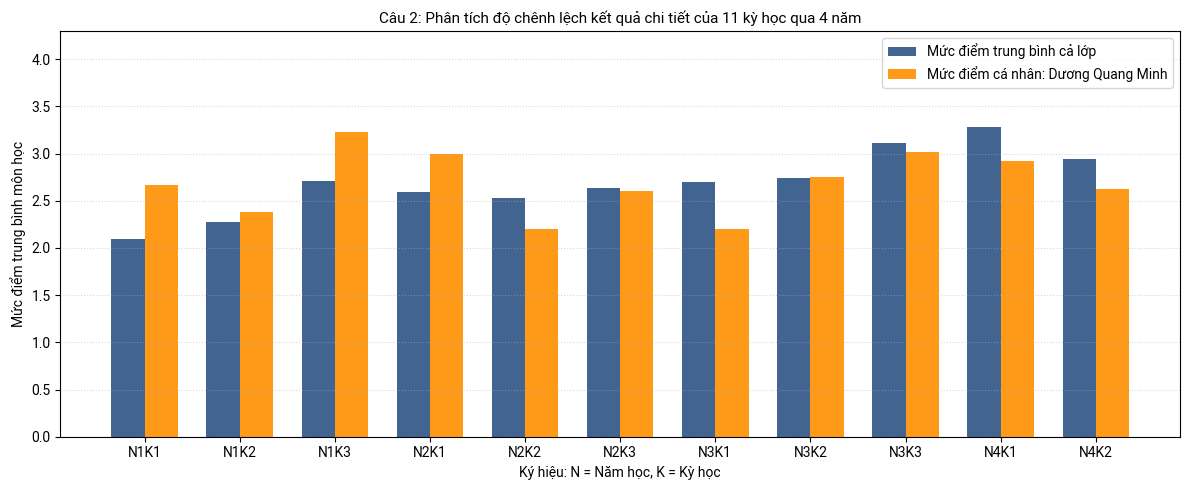

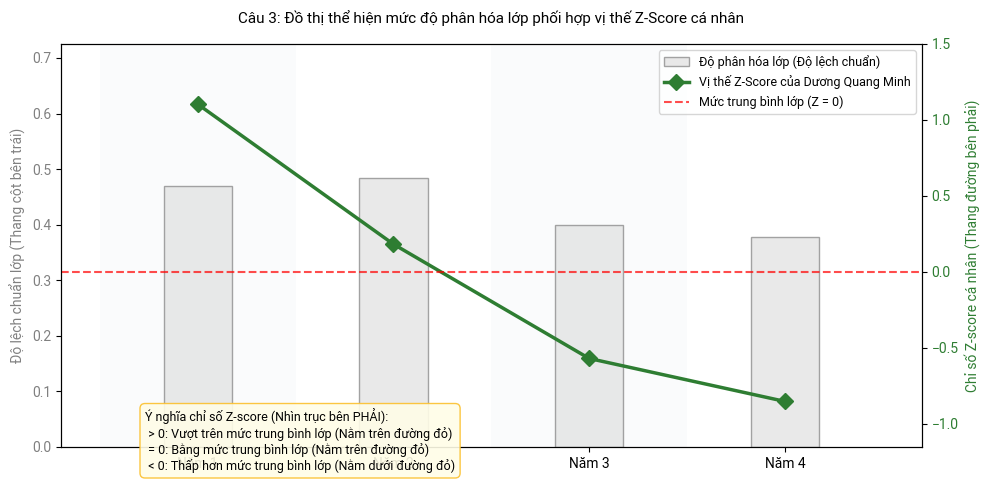

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)


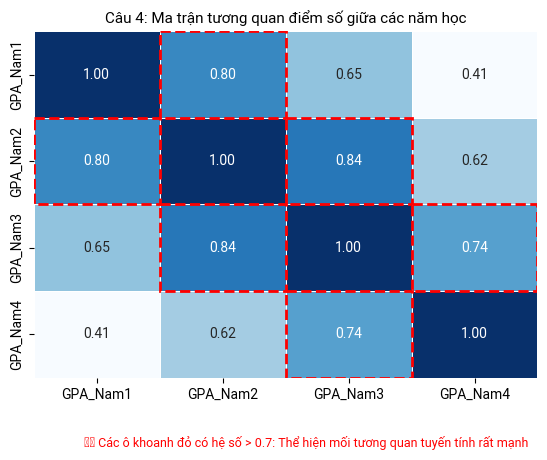

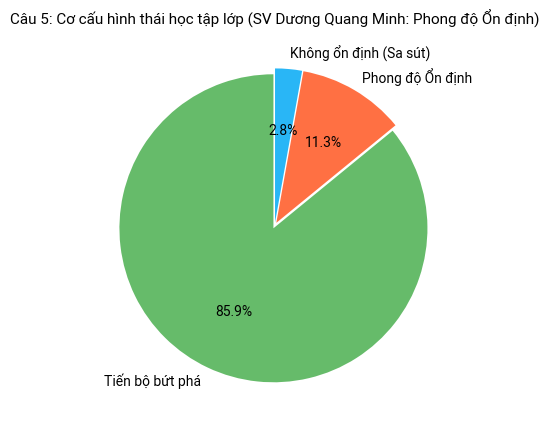

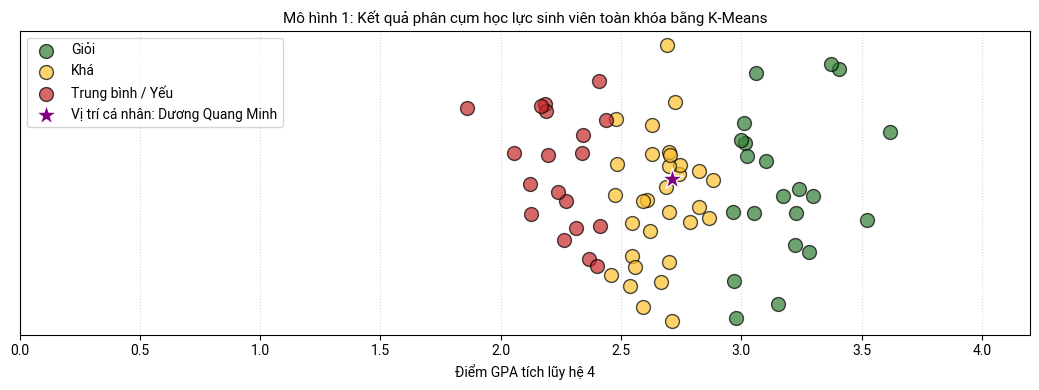

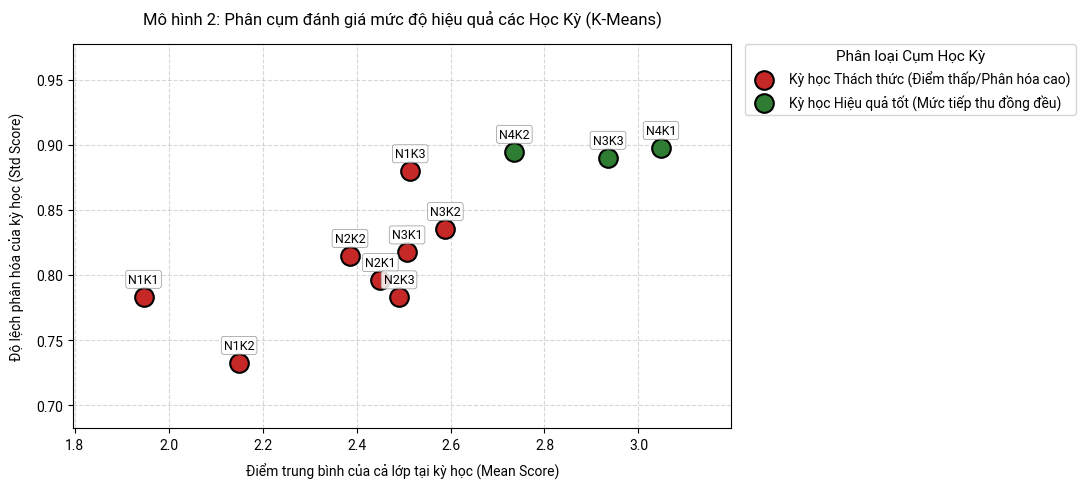

In [55]:
# ==============================================================================
# CELL 6: TRỰC QUAN HÓA ĐỒ THỊ BÁO CÁO (EDA VÀ HỌC MÁY MỞ RỘNG)
# ==============================================================================
import seaborn as sns # Import seaborn for heatmap

years_labels = ['Năm 1', 'Năm 2', 'Năm 3', 'Năm 4']

# --- ĐỒ THỊ CÂU 1: XU HƯỚNG TỔNG QUAN ---
plt.figure(figsize=(9, 4))
plt.plot(years_labels, lop_means, marker='o', color='#1F497D', linewidth=2.5, label='Trung bình lớp')
plt.plot(years_labels, sv_means, marker='s', color='#C62828', linewidth=3, linestyle='--', markersize=8, label=f"SV: {TEN_SV_LUA_CHON}")
plt.title(f'Câu 1: So sánh biến động điểm GPA trung bình năm học', fontsize=11, fontweight='bold')
plt.ylabel('Điểm GPA hệ 4')
plt.ylim(0, 4.3)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# --- ĐỒ THỊ CÂU 2: SO SÁNH 11 KỲ HỌC CHI TIẾT QUA 4 NĂM ---
plt.figure(figsize=(12, 5))
x_axis = np.arange(len(labels_11_ky))
width_b = 0.35
plt.bar(x_axis - width_b/2, lop_means_11_ky, width_b, label='Mức điểm trung bình cả lớp', color='#1F497D', alpha=0.85)
plt.bar(x_axis + width_b/2, sv_means_11_ky, width_b, label=f"Mức điểm cá nhân: {TEN_SV_LUA_CHON}", color='#FF8F00', alpha=0.9)
plt.title('Câu 2: Phân tích độ chênh lệch kết quả chi tiết của 11 kỳ học qua 4 năm', fontsize=11, fontweight='bold')
plt.xticks(x_axis, labels_11_ky)
plt.xlabel('Ký hiệu: N = Năm học, K = Kỳ học')
plt.ylabel('Mức điểm trung bình môn học')
plt.ylim(0, 4.3)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# --- ĐỒ THỊ CÂU 3: ĐỘ PHÂN HÓA VÀ VỊ THẾ CÁ NHÂN  ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1. Vẽ cột thể hiện độ phân hóa lớp (Gióng sang TRỤC TRÁI)
bar_plot = ax1.bar(years_labels, lop_stds, color='#E0E0E0', edgecolor='gray', width=0.35, alpha=0.7,
                   label='Độ phân hóa lớp (Độ lệch chuẩn)')
ax1.set_ylabel('Độ lệch chuẩn lớp (Thang cột bên trái)', color='gray', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='gray')
ax1.set_ylim(0, max(lop_stds) * 1.5)

# 2. Vẽ đường vị thế cá nhân qua chỉ số Z-score (Gióng sang TRỤC PHẢI)
ax2 = ax1.twinx()
line_plot = ax2.plot(years_labels, sv_z_scores, marker='D', color='#2E7D32', linewidth=2.5, markersize=8,
                     label=f"Vị thế Z-Score của {TEN_SV_LUA_CHON}")
ax2.set_ylabel('Chỉ số Z-score cá nhân (Thang đường bên phải)', color='#2E7D32', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2E7D32')

# SỬA LỖI CỐT LÕI: Vẽ đường ranh giới Z = 0 neo chuẩn xác theo tọa độ của TRỤC PHẢI
ax2.axhline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Mức trung bình lớp (Z = 0)')

# Tự động căn chỉnh dải hiển thị trục phải cân đối (đảm bảo hiển thị tốt từ vùng âm đến vùng dương nếu có)
ax2.set_ylim(min(-0.2, min(sv_z_scores) - 0.3), max(1.5, max(sv_z_scores) + 0.3))

# 3. Gộp chú thích ký hiệu (Legend) của cả 2 trục lại làm một cho đẹp mắt
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=9)

# 4. Tạo các mảng màu nền phân định giai đoạn năm học
for i in range(len(years_labels)):
    bg_color = '#F7F9FA' if i % 2 == 0 else '#FFFFFF'
    ax1.axvspan(i-0.5, i+0.5, facecolor=bg_color, alpha=0.5, zorder=-1)

# 5. CẬP NHẬT CHÚ THÍCH HỘP VÀNG: Hướng dẫn gióng trục phải rõ ràng
text_note = (
    "Ý nghĩa chỉ số Z-score (trục phải):\n"
    " > 0: Vượt trên mức trung bình lớp (trên đường đỏ)\n"
    " = 0: Bằng mức trung bình lớp (Nằm trên đường đỏ)\n"
    " < 0: Thấp hơn mức trung bình lớp (dưới đường đỏ)"
)
plt.text(0.15, 0.05, text_note, transform=fig.transFigure, fontsize=9,
         bbox=dict(boxstyle="round,pad=0.4", facecolor='#FFFDE7', edgecolor='#FBC02D', alpha=0.9))

plt.title(f'Câu 3: Đồ thị thể hiện mức độ phân hóa lớp phối hợp vị thế Z-Score cá nhân', fontsize=11, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# --- ĐỒ THỊ CÂU 4: MA TRẬN NHIỆT TƯƠNG QUAN (CHÚ THÍCH HỆ SỐ MẠNH > 0.7) ---
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Câu 4: Ma trận tương quan điểm số giữa các năm học', fontsize=11, fontweight='bold')

# Vòng lặp quét tìm và khoanh tròn/ghi chú các ô có mối liên hệ tương quan rất mạnh (>0.7)
for y_pos in range(4):
    for x_pos in range(4):
        if correlation_matrix.iloc[y_pos, x_pos] > 0.7 and y_pos != x_pos:
            plt.gca().add_patch(plt.Rectangle((x_pos, y_pos), 1, 1, fill=False, edgecolor='red', lw=2, linestyle='--'))

plt.text(0.1, -0.2, "⚠️ Các ô khoanh đỏ có hệ số > 0.7: Thể hiện mối tương quan tuyến tính rất mạnh", color='red', fontsize=9, fontweight='bold', transform=plt.gca().transAxes)
plt.show()

# --- ĐỒ THỊ CÂU 5: CƠ CẤU BIẾN ĐỘNG HÌNH THÁI ---
plt.figure(figsize=(5, 5))
plt.pie(counts_progress, labels=counts_progress.index, autopct='%1.1f%%',
        colors=['#66BB6A', '#FF7043', '#29B6F6'], startangle=90, explode=(0.02, 0.02, 0.02))
plt.title(f'Câu 5: Cơ cấu hình thái học tập lớp (SV {TEN_SV_LUA_CHON}: {sv_progress_label})', fontsize=11, fontweight='bold')
plt.show()

# --- ĐỒ THỊ MÔ HÌNH HỌC MÁY 1: BIỂU ĐỒ PHÂN TÁN PHÂN CỤM SINH VIÊN ---
plt.figure(figsize=(10.5, 4))
colors_map = {"Giỏi": '#2E7D32', "Khá": '#FBC02D', "Trung bình / Yếu": '#C62828'}
groups_list = ["Giỏi", "Khá", "Trung bình / Yếu"]

np.random.seed(42)
for group_name in groups_list:
    sub_df = features_filtered[features_filtered['Ten_Nhom_Cum'] == group_name]
    y_jitter = np.random.normal(0, 0.04, size=len(sub_df))
    plt.scatter(sub_df['GPA'], y_jitter, c=colors_map[group_name], label=group_name, s=100, edgecolors='black', alpha=0.7)

plt.scatter([sv_data['GPA']], [0.0], color='purple', edgecolors='white', s=250, marker='*', label=f"Vị trí cá nhân: {TEN_SV_LUA_CHON}", zorder=5)
plt.title(f'Mô hình 1: Kết quả phân cụm học lực sinh viên toàn khóa bằng K-Means', fontsize=11, fontweight='bold')
plt.xlabel('Điểm GPA tích lũy hệ 4')
plt.xlim(0.0, 4.2)
plt.gca().get_yaxis().set_visible(False)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- ĐỒ THỊ MÔ HÌNH HỌC MÁY 2: PHÂN CỤM HỌC KỲ ---
plt.figure(figsize=(11, 5))

colors_hk = {
    "Kỳ học Hiệu quả tốt (Mức tiếp thu đồng đều)": '#2E7D32',
    "Kỳ học Thách thức (Điểm thấp/Phân hóa cao)": '#C62828'
}

# Vẽ các điểm phân cụm
for cluster_name in hk_mapping.values():
    sub_hk = features_hk[features_hk['Ten_Cum_Ky'] == cluster_name]
    if len(sub_hk) > 0:
        plt.scatter(sub_hk['Mean_Score'], sub_hk['Std_Score'], s=180,
                    color=colors_hk[cluster_name], label=cluster_name,
                    edgecolors='black', linewidths=1.5, zorder=3)

        # Thêm nhãn tên từng học kỳ (Ví dụ: N1K1, N2K3...) một cách rõ ràng
        for name in sub_hk.index:
            plt.annotate(
                name,
                (sub_hk.loc[name, 'Mean_Score'], sub_hk.loc[name, 'Std_Score']),
                textcoords="offset points", # Định vị tọa độ tương đối theo điểm pixel
                xytext=(0, 10),              # Đẩy chữ lên phía trên chấm tròn 10 pixel
                ha='center',
                fontweight='bold',
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5, alpha=0.85), # Thêm nền trắng nhẹ cho chữ dễ đọc
                zorder=4
            )

plt.title('Mô hình 2: Phân cụm đánh giá mức độ hiệu quả các Học Kỳ (K-Means)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Điểm trung bình của cả lớp tại kỳ học (Mean Score)', fontsize=10, labelpad=8)
plt.ylabel('Độ lệch phân hóa của kỳ học (Std Score)', fontsize=10, labelpad=8)
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

# NỚI RỘNG KHÔNG GIAN TRỤC ĐỂ CHỮ KHÔNG BỊ TRÀN RA NGOÀI KHUNG BIỂU ĐỒ
x_min, x_max = features_hk['Mean_Score'].min(), features_hk['Mean_Score'].max()
y_min, y_max = features_hk['Std_Score'].min(), features_hk['Std_Score'].max()
plt.xlim(x_min - 0.15, x_max + 0.15)
plt.ylim(y_min - 0.05, y_max + 0.08)

# ĐẨY HỘP CHÚ THÍCH (LEGEND) RA HẲN BÊN NGOÀI BIỂU ĐỒ (PHÍA BÊN PHẢI)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1), # Tọa độ x=1.02 dịch hẳn sang phải đường biên đồ thị
    borderaxespad=0,
    fontsize=10,
    title="Phân loại Cụm Học Kỳ",
    title_fontsize=11
)

plt.tight_layout()
plt.show()

In [56]:
# ==============================================================================
# CELL 7: SẮP XẾP DANH SÁCH, XUẤT EXCEL ĐỊNH DẠNG ĐẸP & XUẤT BÁO CÁO WORD
# ==============================================================================
import io
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Kích hoạt thư viện tạo file Word báo cáo
try:
    import docx
    from docx.shared import Inches
except ImportError:
    print("Đang tiến hành cài đặt bổ sung thư viện python-docx...")
    !pip install python-docx
    import docx
    from docx.shared import Inches

# ------------------------------------------------------------------------------
# PHẦN 1: TẠO VÀ ĐỊNH DẠNG FILE EXCEL CẤU TRÚC ĐẸP (KẾ THỪA LOGIC FILE GỐC)
# ------------------------------------------------------------------------------
print("=== GIAI ĐOẠN 1: ĐANG KHỞI TẠO FILE EXCEL BÁO CÁO TIẾN TRÌNH ===")
wb = Workbook()

# --- SHEET 1: TOÀN BỘ DANH SÁCH LỚP PHÂN THEO CỤM CHUỖI THỜI GIAN ---
ws1 = wb.active
ws1.title = "Tien Trinh Lop K58KTP"
ws1.views.sheetView[0].showGridLines = True

# Định nghĩa bảng màu sắc và phông chữ chuẩn doanh nghiệp
FONT_TITLE = Font(name="Times New Roman", size=15, bold=True, color="1F497D")
FONT_HEADER = Font(name="Times New Roman", size=11, bold=True, color="FFFFFF")
FONT_TEXT = Font(name="Times New Roman", size=11, bold=False)
FONT_TEXT_BOLD = Font(name="Times New Roman", size=11, bold=True)

FILL_HEADER = PatternFill('solid', start_color='1F497D', end_color='1F497D')
FILL_GIOI = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')  # Xanh lá nhạt
FILL_KHA = PatternFill('solid', start_color='FFF2CC', end_color='FFF2CC')   # Vàng nhạt
FILL_YEU = PatternFill('solid', start_color='FCE4D6', end_color='FCE4D6')   # Cam đỏ nhạt

BORDER_THIN = Border(
    left=Side(style='thin', color='D9D9D9'), right=Side(style='thin', color='D9D9D9'),
    top=Side(style='thin', color='D9D9D9'), bottom=Side(style='thin', color='D9D9D9')
)

# Viết tiêu đề lớn cho Sheet 1
ws1.merge_cells("A1:G1")
ws1["A1"] = "BẢNG PHÂN CỤM HỌC LỰC TIẾN TRÌNH LỚP K58KTP"
ws1["A1"].font = FONT_TITLE
ws1["A1"].alignment = Alignment(horizontal='center', vertical='center')
ws1.row_dimensions[1].height = 35

# Thiết lập Header cột dữ liệu
headers_excel = ["STT", "MSSV", "Tên Sinh Viên", "GPA_Nam1", "GPA_Nam2", "GPA_Nam3", "GPA_Nam4", "GPA_ToanKhoa", "Hình Thái", "Cụm Học Lực"]
for col_idx, h_text in enumerate(headers_excel, 1):
    cell = ws1.cell(row=3, column=col_idx, value=h_text)
    cell.font = FONT_HEADER
    cell.fill = FILL_HEADER
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
ws1.row_dimensions[3].height = 25

# Sắp xếp danh sách sinh viên theo thứ tự ưu tiên học lực: Giỏi -> Khá -> Trung bình / Yếu
features_sorted = features_filtered.sort_values(by=['Cluster_Label', 'GPA'], ascending=[False, False]).reset_index(drop=True)

# Đổ dữ liệu thực tế và phối màu theo nhóm cụm tương ứng
row_num = 4
for idx, row in features_sorted.iterrows():
    # Lựa chọn màu sắc theo từng nhãn cụm học lực
    if row['Ten_Nhom_Cum'] == "Giỏi": current_fill = FILL_GIOI
    elif row['Ten_Nhom_Cum'] == "Khá": current_fill = FILL_KHA
    else: current_fill = FILL_YEU

    data_row = [
        idx + 1, row['MSSV'], row['Ten_SV'],
        round(row['GPA_Nam1'], 2), round(row['GPA_Nam2'], 2),
        round(row['GPA_Nam3'], 2), round(row['GPA_Nam4'], 2),
        round(row['GPA'], 2), row['Hinh_Thai_Tien_Trinh'], row['Ten_Nhom_Cum']
    ]

    for col_idx, val in enumerate(data_row, 1):
        cell = ws1.cell(row=row_num, column=col_idx, value=val)
        cell.font = FONT_TEXT
        cell.border = BORDER_THIN
        cell.fill = current_fill

        # Định dạng căn lề và số thập phân
        if col_idx in [1, 2, 9, 10]:
            cell.alignment = Alignment(horizontal='center', vertical='center')
        elif col_idx in [4, 5, 6, 7, 8]:
            cell.alignment = Alignment(horizontal='right', vertical='center')
            cell.number_format = '0.00'
        else:
            cell.alignment = Alignment(horizontal='left', vertical='center')

    ws1.row_dimensions[row_num].height = 20
    row_num += 1

# Tự động tối ưu độ rộng các cột (Auto-fit column width)
for col in ws1.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    col_letter = get_column_letter(col[0].column)
    ws1.column_dimensions[col_letter].width = max(max_len + 4, 12)

excel_filename = "Ket_Qua_Tien_Trinh_K58KTP.xlsx"
wb.save(excel_filename)
print(f" Xuất file Excel thành công! Đã lưu: {excel_filename}")


# ------------------------------------------------------------------------------
# PHẦN 2: CHỤP LẠI BIỂU ĐỒ TỪ CELL 6 VÀ TỰ ĐỘNG XUẤT FILE WORD BÁO CÁO
# ------------------------------------------------------------------------------
print("\n=== GIAI ĐOẠN 2: ĐANG TỰ ĐỘNG CHỤP BIỂU ĐỒ VÀ KHỞI TẠO FILE WORD BÁO CÁO ===")

# Khởi tạo đối tượng tài liệu Word Word Document
doc = docx.Document()

# Thiết lập tiêu đề báo cáo trong file Word
title_doc = doc.add_paragraph()
run_title = title_doc.add_run("BÁO CÁO PHÂN TÍCH TIẾN TRÌNH ĐIỂM SỐ VÀ MÔ HÌNH HỌC MÁY LỚP K58KTP")
run_title.font.name = 'Times New Roman'
run_title.font.size = docx.shared.Pt(16)
run_title.font.bold = True
title_doc.alignment = docx.enum.text.WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(f"Đối tượng sinh viên lựa chọn phân tích chi tiết: {TEN_SV_LUA_CHON}\n")

# Định nghĩa hàm phụ trợ để dựng lại từng đồ thị từ Cell 6 và lưu trực tiếp vào file Word
def nhung_bieu_do_vao_word(index_id, title_text, plot_func):
    doc.add_heading(f"{index_id}. {title_text}", level=2)

    # Tạo luồng bộ nhớ tạm thời lưu ảnh mà không cần ghi file ra đĩa cứng
    img_stream = io.BytesIO()

    # Gọi hàm dựng đồ thị độc lập
    plt.figure(figsize=(9, 4.5))
    plot_func()

    # Ghi cấu trúc đồ thị vào luồng ảnh PNG
    plt.savefig(img_stream, format='png', dpi=150, bbox_inches='tight')
    plt.close()
    img_stream.seek(0)

    # Nhúng trực tiếp luồng ảnh vào văn bản Word
    doc.add_picture(img_stream, width=Inches(6.0))
    doc.add_paragraph(f"Hình {index_id}: Biểu đồ trực quan hóa số liệu kết quả cho {title_text}.\n")

# --- Lần lượt chạy tái dựng và chụp 7 đồ thị sang Word ---

def plot_c1():
    plt.plot(years_labels, lop_means, marker='o', color='#1F497D', linewidth=2.5, label='Trung bình lớp')
    plt.plot(years_labels, sv_means, marker='s', color='#C62828', linewidth=3, linestyle='--', markersize=8, label=f"SV: {TEN_SV_LUA_CHON}")
    plt.ylabel('Điểm GPA hệ 4'); plt.ylim(0, 4.3); plt.legend(); plt.grid(True, linestyle=':', alpha=0.5)
nhung_bieu_do_vao_word("1", "Xu hướng biến động điểm GPA trung bình năm học", plot_c1)

def plot_c2():
    x_axis = np.arange(len(labels_11_ky))
    width_b = 0.35
    plt.bar(x_axis - width_b/2, lop_means_11_ky, width_b, label='Mức điểm trung bình cả lớp', color='#1F497D', alpha=0.85)
    plt.bar(x_axis + width_b/2, sv_means_11_ky, width_b, label=f"Mức điểm cá nhân: {TEN_SV_LUA_CHON}", color='#FF8F00', alpha=0.9)
    plt.xticks(x_axis, labels_11_ky); plt.ylabel('Mức điểm hệ 4'); plt.ylim(0, 4.3); plt.legend(loc='upper right'); plt.grid(axis='y', linestyle=':', alpha=0.5)
nhung_bieu_do_vao_word("2", "Phân tích độ chênh lệch kết quả chi tiết của 11 kỳ học qua 4 năm", plot_c2)

def plot_c3():
    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    ax1.bar(years_labels, lop_stds, color='#E0E0E0', edgecolor='gray', width=0.35, alpha=0.7)
    ax1.set_ylabel('Độ lệch chuẩn lớp', color='gray')
    ax2 = ax1.twinx()
    ax2.plot(years_labels, sv_z_scores, marker='D', color='#2E7D32', linewidth=2.5, markersize=8)
    ax2.set_ylabel('Chỉ số Z-score cá nhân', color='#2E7D32')
    ax2.axhline(0, color='red', linestyle=':', alpha=0.6)
    for i in range(len(years_labels)):
        ax1.axvspan(i-0.5, i+0.5, facecolor='#F7F9FA' if i % 2 == 0 else '#FFFFFF', alpha=0.5, zorder=-1)
nhung_bieu_do_vao_word("3", "Đồ thị mức độ phân hóa lớp phối hợp vị thế Z-Score cá nhân", plot_c3)

def plot_c4():
    sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, cbar=False)
nhung_bieu_do_vao_word("4", "Ma trận tương quan điểm số giữa các năm học của tập thể lớp", plot_c4)

def plot_c5():
    plt.pie(counts_progress, labels=counts_progress.index, autopct='%1.1f%%', colors=['#66BB6A', '#FF7043', '#29B6F6'], startangle=90)
nhung_bieu_do_vao_word("5", "Cơ cấu tỷ lệ phần trăm các hình thái học tập của lớp", plot_c5)

def plot_m1():
    colors_map = {"Giỏi": '#2E7D32', "Khá": '#FBC02D', "Trung bình / Yếu": '#C62828'}
    for group_name in ["Giỏi", "Khá", "Trung bình / Yếu"]:
        sub_df = features_filtered[features_filtered['Ten_Nhom_Cum'] == group_name]
        plt.scatter(sub_df['GPA'], np.random.normal(0, 0.04, size=len(sub_df)), c=colors_map[group_name], label=group_name, s=100, edgecolors='black', alpha=0.7)
    plt.scatter([sv_data['GPA']], [0.0], color='purple', edgecolors='white', s=250, marker='*', label=f"SV: {TEN_SV_LUA_CHON}", zorder=5)
    plt.xlim(0.0, 4.2); plt.gca().get_yaxis().set_visible(False); plt.grid(axis='x', linestyle=':'); plt.legend(loc='upper left')
nhung_bieu_do_vao_word("6", "Mô hình học máy 1 - Kết quả phân cụm học lực sinh viên bằng K-Means", plot_m1)

def plot_m2():
    colors_hk = {"Kỳ học Hiệu quả tốt (Mức tiếp thu đồng đều)": '#2E7D32', "Kỳ học Thách thức (Điểm thấp/Phân hóa cao)": '#C62828'}
    for cluster_name in hk_mapping.values():
        sub_hk = features_hk[features_hk['Ten_Cum_Ky'] == cluster_name]
        if len(sub_hk) > 0:
            plt.scatter(sub_hk['Mean_Score'], sub_hk['Std_Score'], s=150, color=colors_hk[cluster_name], label=cluster_name, edgecolors='black', zorder=3)
            for name in sub_hk.index: plt.annotate(name, (sub_hk.loc[name, 'Mean_Score'], sub_hk.loc[name, 'Std_Score'] + 0.01), ha='center', fontweight='bold')
    plt.xlabel('Mean Score'); plt.ylabel('Std Score'); plt.grid(True, linestyle=':'); plt.legend(loc='upper right', fontsize=9)
nhung_bieu_do_vao_word("7", "Mô hình học máy 2 - Kết quả phân cụm đánh giá mức độ hiệu quả các Học Kỳ", plot_m2)

# Lưu văn bản báo cáo Word hoàn chỉnh xuống thư mục làm việc
word_filename = "Bao_Cao_Bieu_Do_K58KTP.docx"
doc.save(word_filename)
print(f" Xuất file báo cáo Word thành công! Đã lưu: {word_filename}")

print("\n" + "="*80)
print("📍 ĐƯỜNG DẪN VỊ TRÍ LƯU FILE TRÊN HỆ THỐNG:")
print(f"1. File báo cáo Excel: {os.path.abspath(excel_filename)}")
print(f"2. File báo cáo Word:  {os.path.abspath(word_filename)}")
print("="*80)
print("\n>>> QUÁ TRÌNH XUẤT TÀI LIỆU HOÀN TẤT.<<<")

=== GIAI ĐOẠN 1: ĐANG KHỞI TẠO FILE EXCEL BÁO CÁO TIẾN TRÌNH ===
 Xuất file Excel thành công! Đã lưu: Ket_Qua_Tien_Trinh_K58KTP.xlsx

=== GIAI ĐOẠN 2: ĐANG TỰ ĐỘNG CHỤP BIỂU ĐỒ VÀ KHỞI TẠO FILE WORD BÁO CÁO ===
 Xuất file báo cáo Word thành công! Đã lưu: Bao_Cao_Bieu_Do_K58KTP.docx

📍 ĐƯỜNG DẪN VỊ TRÍ LƯU FILE TRÊN HỆ THỐNG:
1. File báo cáo Excel: /content/Ket_Qua_Tien_Trinh_K58KTP.xlsx
2. File báo cáo Word:  /content/Bao_Cao_Bieu_Do_K58KTP.docx

>>> QUÁ TRÌNH XUẤT TÀI LIỆU HOÀN TẤT.<<<


<Figure size 900x450 with 0 Axes>